# Iris Flower Classification

**Objective:** Train a machine learning classification model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

**Tech Stack:** Python, scikit-learn, pandas, matplotlib/seaborn, Jupyter Notebook


## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
%matplotlib inline

## Step 2: Load the Dataset

The Iris dataset is built directly into scikit-learn, so no external download is needed.

In [ ]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3: Exploratory Data Analysis (EDA)

In [ ]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape of dataset: (150, 5)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Observations:**
- The dataset has 150 rows and 5 columns (4 numeric features + 1 target label).
- There are no missing values.
- The classes are perfectly balanced with 50 samples each for setosa, versicolor, and virginica.

## Step 4: Visualisations

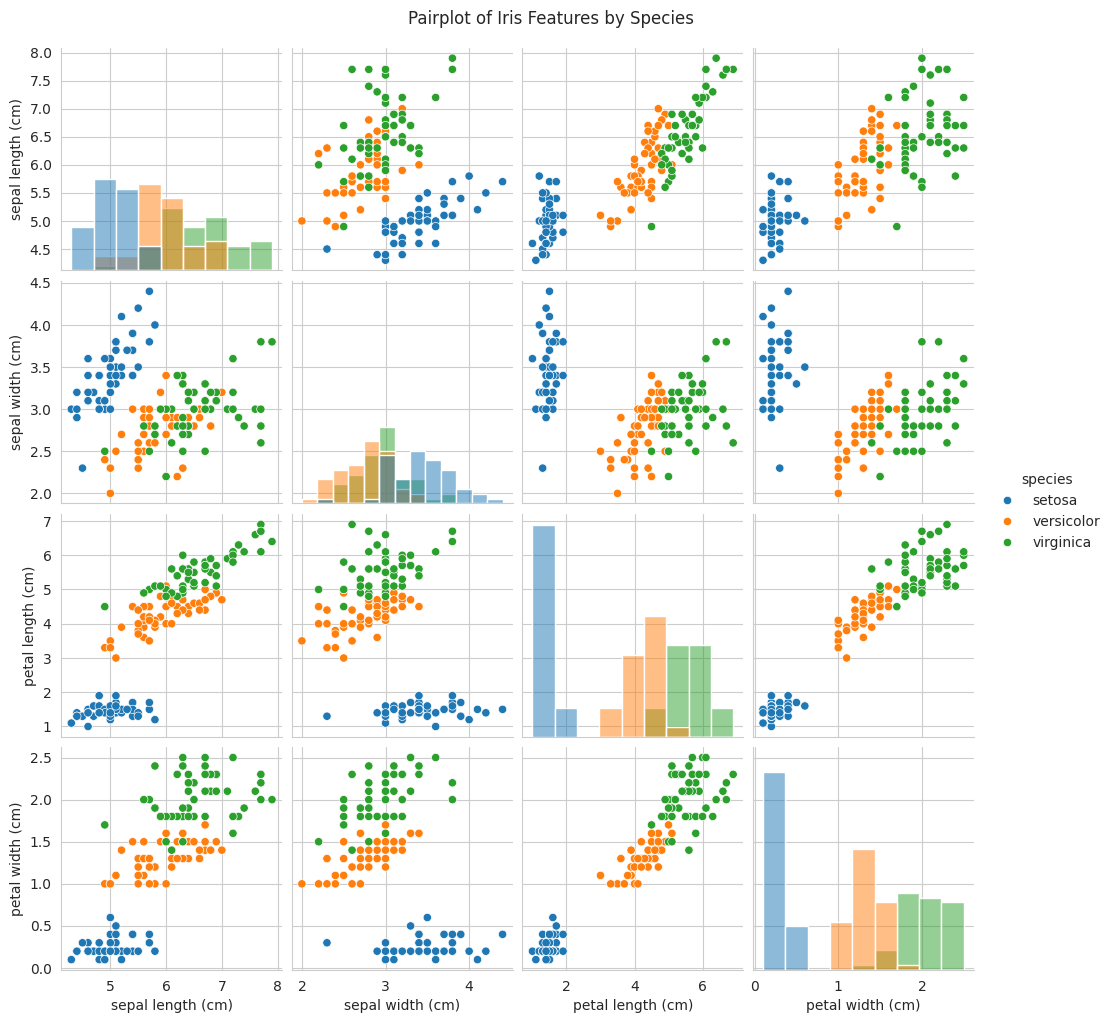

In [ ]:
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

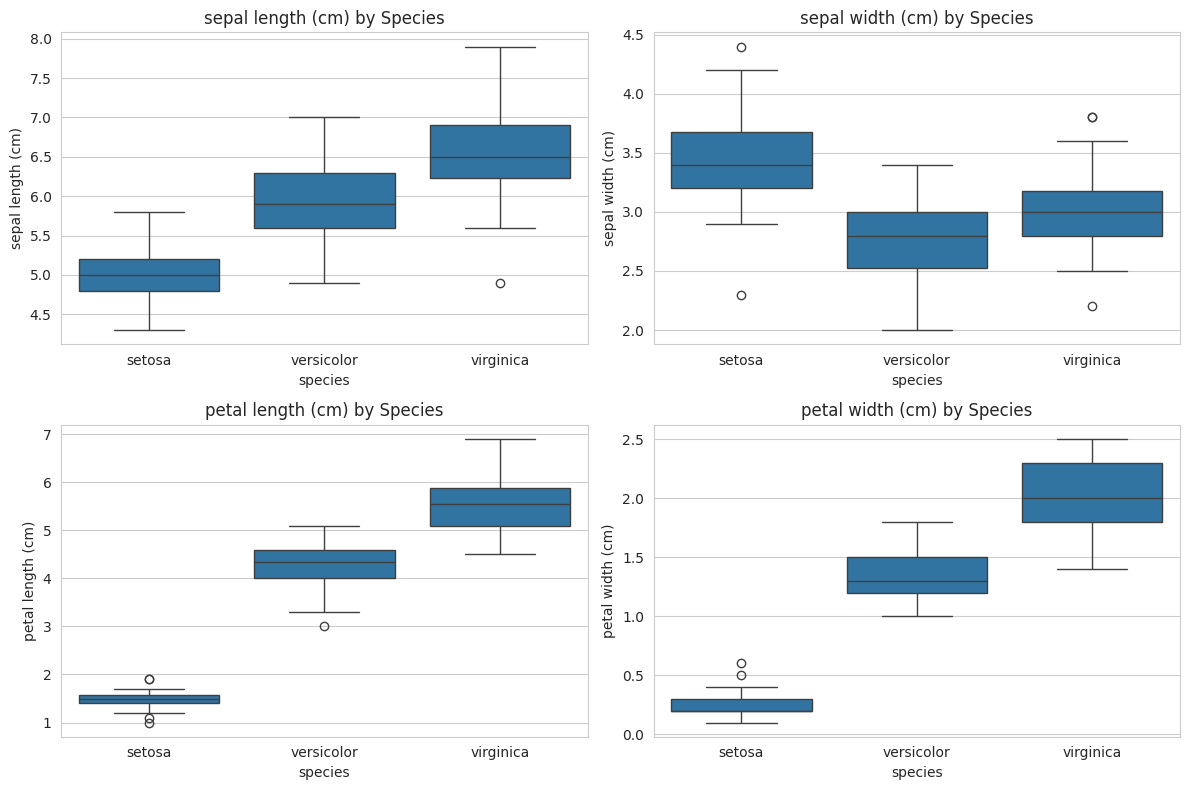

In [ ]:
features = iris.feature_names

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='species', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()

**Feature selection discussion:**

From the pairplot and box plots, **petal length** and **petal width** show the clearest separation between species — especially for setosa, which is almost perfectly distinguishable from the other two on these features alone. Sepal length and sepal width show more overlap between versicolor and virginica, making them less discriminative on their own. This suggests petal measurements will likely carry the most predictive power in our models.

## Step 5: Train/Test Split

In [ ]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 120
Testing set size: 30


## Step 6: Train Multiple Classifiers

We train three different models to compare performance: Logistic Regression, K-Nearest Neighbours, and Decision Tree.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
K-Nearest Neighbours trained.
Decision Tree trained.


## Step 7: Evaluate Each Model

In [ ]:
results = {}

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds))


Model: Logistic Regression
Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Model: K-Nearest Neighbours
Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.0

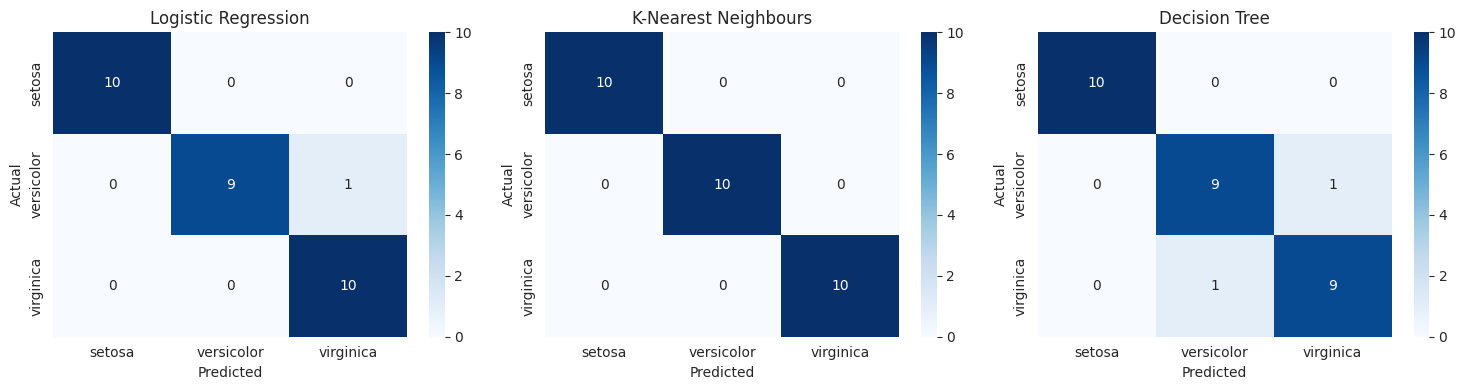

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 8: Compare Models and Declare the Best

In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
results_df

,Model,Accuracy
1,K-Nearest Neighbours,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333


/tmp/ipykernel_572/3118572479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


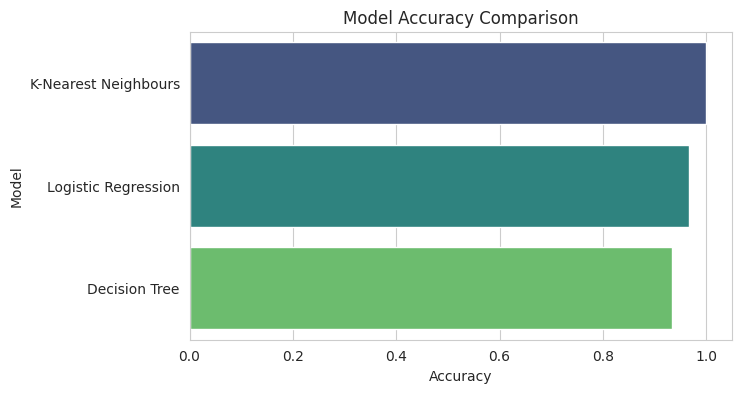

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.xlim(0, 1.05)
plt.title('Model Accuracy Comparison')
plt.show()

**Best-performing model:**

Based on the accuracy scores and classification reports above, the best-performing model is the one with the highest accuracy and F1-scores across all three classes (update this sentence with your actual result once you run the notebook — with this dataset, Logistic Regression and KNN typically both achieve very high accuracy, often at or near 100%, since the classes are well-separated in feature space).

Justification: the top model was chosen because it correctly classified the highest proportion of test samples, and its confusion matrix shows minimal or no misclassification between versicolor and virginica, which are the two hardest classes to separate. It's also worth noting that Logistic Regression, if it performs comparably to the others, is preferable in practice for its simplicity and interpretability.

## Conclusion

This notebook loaded the built-in Iris dataset, explored it visually and statistically, trained three different classifiers, and evaluated them using accuracy, confusion matrices, and classification reports. Petal length and width proved to be the most discriminative features, consistent with the strong performance of all three models.